# 3 Apr 2026
- basic notebook that samples IPTA MDC1 in principal maps using discovery -- new specspat formalism

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
from jax.scipy import stats as jss
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from discovery.glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac
from PTMCMCSampler import PTMCMCSampler
import matplotlib.patches as mpatches

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

## broadband analysis

In [5]:
# psrs = mdcpsrs
# T = ds.getspan(psrs)
# comps = 6 # freq components
# lmx = 6
# nsi=1

# psrpos = np.array([p.pos for p in psrs])

# lsphorf = dac.get_linspharm_orf(psrpos, lmax=lmx)

# glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
#                                     [[functools.partial(lsphorf, c00=np.sqrt(4*np.pi))]],
#                                     components=comps, T=T, name='gw', nbasis=[[(lmx+1)**2-1]])


# # m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
# #                                              ds.makenoise_measurement_simple(psr),
# #                                              ds.makegp_timing(psr, svd=True)]) for psr in psrs],
# #                        commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
# #                        globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


# mdc_jlogl = jax.jit(m_mdc.logL)

In [6]:
psrs = mdcpsrs
psrpos = np.array([p.pos for p in psrs])

pmaporf, basismaps = dac.get_principalmap_pixelbasis_orf(psrpos, perc_sv=0.9)


In [7]:
pmaporf

<PjitFunction of <function get_principalmap_pixelbasis_orf.<locals>.principalmap_orf at 0x7b07f42942c0>>

In [8]:
basismaps.shape

(23, 3072)

In [9]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 6 # freq components
lmx = 6
nsi=1
nclms = (lmx+1)**2-1

ndict = {f'{p.name}_efac': 1.0 for p in psrs}
ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})

psrpos = np.array([p.pos for p in psrs])

pmaporf, basismaps = dac.get_principalmap_pixelbasis_orf(psrpos, perc_sv=0.7)

nanisopars = basismaps.shape[0]

glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
                                    [[pmaporf]],
                                    components=comps, T=T, name='gw', nbasis=[[nanisopars]])


m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makegp_timing(psr, svd=True)]) for psr in psrs],
                       commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
                       globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

@jax.jit
def constrn_like(params):
    paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
    paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
    paramdict[f'gw_amps({nanisopars})'] = params[:nanisopars]
    paramdict['gw_gamma'] = params[-2]
    paramdict['gw_log10_A'] = params[-1]
    return m_mdc.logL(paramdict)

nanisopars = basismaps.shape[0]
nparams = nanisopars + 2

In [10]:
mdc_jlogl.params

['J0030+0451_rednoise_gamma',
 'J0030+0451_rednoise_log10_A',
 'J0218+4232_rednoise_gamma',
 'J0218+4232_rednoise_log10_A',
 'J0437-4715_rednoise_gamma',
 'J0437-4715_rednoise_log10_A',
 'J0613-0200_rednoise_gamma',
 'J0613-0200_rednoise_log10_A',
 'J0621+1002_rednoise_gamma',
 'J0621+1002_rednoise_log10_A',
 'J0711-6830_rednoise_gamma',
 'J0711-6830_rednoise_log10_A',
 'J0751+1807_rednoise_gamma',
 'J0751+1807_rednoise_log10_A',
 'J0900-3144_rednoise_gamma',
 'J0900-3144_rednoise_log10_A',
 'J1012+5307_rednoise_gamma',
 'J1012+5307_rednoise_log10_A',
 'J1022+1001_rednoise_gamma',
 'J1022+1001_rednoise_log10_A',
 'J1024-0719_rednoise_gamma',
 'J1024-0719_rednoise_log10_A',
 'J1045-4509_rednoise_gamma',
 'J1045-4509_rednoise_log10_A',
 'J1455-3330_rednoise_gamma',
 'J1455-3330_rednoise_log10_A',
 'J1600-3053_rednoise_gamma',
 'J1600-3053_rednoise_log10_A',
 'J1603-7202_rednoise_gamma',
 'J1603-7202_rednoise_log10_A',
 'J1640+2224_rednoise_gamma',
 'J1640+2224_rednoise_log10_A',
 'J1643-

In [11]:
def plot_map(pixelvals):
    hp.mollview(pixelvals, rot=180)
    dac.plot_pulsars(mdcpsrs)
    plt.show()

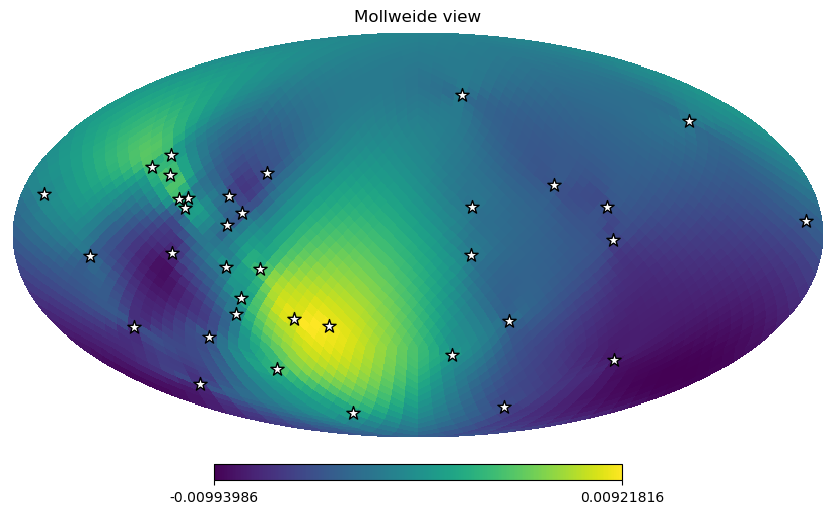

In [12]:
plot_map(np.sum(basismaps.T * np.ones(nanisopars) * 0.1, axis=1))

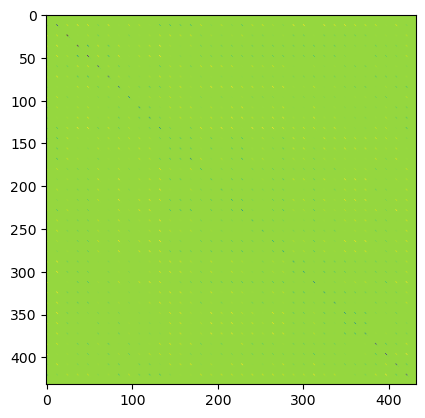

In [13]:
tstdict = {}
tstdict[f'gw_amps({nanisopars})'] = np.ones(nanisopars) * 0.1
tstdict['gw_gamma'] = 13/3
tstdict['gw_log10_A'] = -16

tstphi = m_mdc.globalgp.Phi.getN(tstdict)
tstphiinv = m_mdc.globalgp.Phi_inv(tstdict)[0]
plt.imshow(m_mdc.globalgp.Phi.getN(tstdict))

In [14]:
nanisopars

7

In [15]:
validamps = []

while len(validamps) < 10:
    randamps = np.random.uniform(low=-5, high=5, size=nanisopars)
    smap = np.sum(basismaps.T * randamps, axis=1)
    invalidsky = np.sum(smap < 0) > 0 # True if sky has negative values
    if not invalidsky:
        validamps.append(randamps)
        print(len(validamps))

1
2
3
4
5
6
7
8
9
10


In [16]:
validpars = np.zeros(nparams)
validpars[-2] = 13/3
validpars[-1] = -16
validpars[:nanisopars] = validamps[0]
for i in range(10):
    print(constrn_like(validamps[i]))

34461.07888175442
32686.450868515618
32808.840822405706
33551.04787508164
33289.9899123137
35710.06799011635
33677.24920037309
33950.10342128335
32192.523256419634
32880.48676715598


In [17]:
validamps

[array([-3.06980571, -0.31711754,  0.32500718,  0.62210142,  0.63880537,
        -0.12046092, -1.1963208 ]),
 array([-4.90235999, -0.91227958, -2.81940701,  0.45604113, -0.89931468,
        -1.46166714,  0.65030405]),
 array([-4.47394688, -2.58047136, -1.88477047, -0.23370136, -0.52593126,
         1.25040267,  0.23544374]),
 array([-4.79381037, -2.24475622, -1.9638566 ,  0.31026083, -0.14820375,
        -0.54442531, -0.33106153]),
 array([-4.86521522, -1.18496547, -0.98667935,  1.37943202, -0.38608778,
        -2.28183841,  0.12883639]),
 array([-4.27695915, -2.30052032, -0.74280421,  0.63492769, -0.20347193,
        -0.54014218, -2.49281234]),
 array([-4.72718769, -1.17425459,  0.48832058, -0.45759464, -2.1573868 ,
        -0.46509279, -0.45801425]),
 array([-4.66602831, -1.878827  , -1.77515364,  0.59499324,  0.75950198,
         0.10412636, -0.8000451 ]),
 array([-4.9211725 ,  0.5519946 , -2.0386353 , -0.29998218, -0.82943551,
         2.04349206,  0.77160125]),
 array([-4.36333372

In [18]:
%timeit constrn_like(validpars).block_until_ready()

5.39 ms ± 139 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [19]:
l10apri = lambda x: jss.uniform.logpdf(x, -18, 6)
gampri = lambda x: jss.uniform.logpdf(x, 0, 7)
amppri = lambda x: jss.uniform.logpdf(x, -5, 10)

@jax.jit
def priorfunc(params):
    amps = params[:nanisopars]
    gamma = params[-2]
    log10A = params[-1]
    ampprival = jnp.sum(amppri(amps))
    gamprival = gampri(gamma)
    l10Aprival = l10apri(log10A)
    fullpri = ampprival + gamprival + l10Aprival

    # LSS physicality prior: check if the sky map has negative values
    smap = np.sum(basismaps.T * params[:nanisopars], axis=1)
    invalidsky = jnp.sum(smap < 0) > 0 # True if sky has negative values
    ret = jnp.where(invalidsky, -jnp.inf, fullpri)
    return ret

priorfunc(validpars)


Array(-19.85576527, dtype=float64)

In [20]:
%timeit priorfunc(validpars).block_until_ready()

23.5 μs ± 307 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [21]:
prigrad = jax.grad(priorfunc)
likgrad = jax.grad(constrn_like)

# prigradjump = lambda x: (priorfunc(x), prigrad(x))
# prigradlike = lambda x: (constrn_like(x), likgrad(x))

def prigradjump(x):
    return np.float64(priorfunc(x)).item(), np.array(prigrad(x))

def likegradjump(x):
    return np.float64(constrn_like(x)).item(), np.array(likgrad(x))

In [24]:
initcov = np.eye(nparams) * 0.01
sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc,
                                   #logl_grad=likegradjump, logp_grad=prigradjump,
                                   cov=initcov,
                                   outDir='./chains/broad_pmap/', resume=False)

In [25]:
sampler.sample(Niter=10000, p0=np.array(validpars),
               SCAMweight=25, AMweight=25, DEweight=50)

Finished 0.00 percent in 0.005217 s Acceptance rate = 0

Finished 100.00 percent in 38.248236 s Acceptance rate = 0.20317
Run Complete


## Looking at the chain

In [26]:
chn = np.loadtxt('/home/levis/ipta_aniso_datachallenge/examples/principalmaps/chains/broad_pmap/chain_1.txt')

In [27]:
chn.shape

(1001, 13)

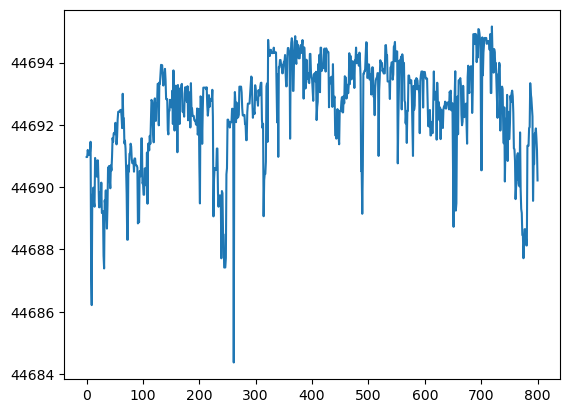

In [30]:
plt.plot(chn[200:, -4])

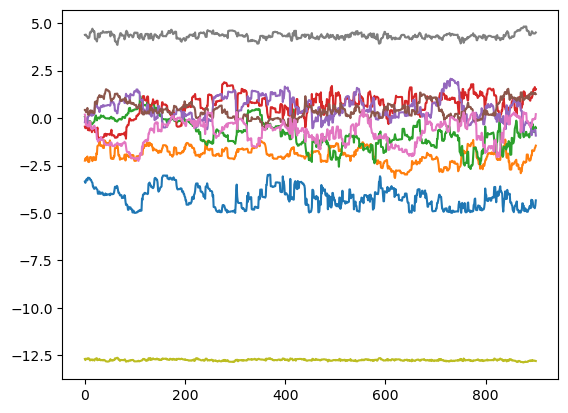

In [31]:
for i in range(nparams):
    plt.plot(chn[100:, i])

In [32]:
truevals = np.zeros(nparams)
truevals[-2] = 13/3
truevals[-1] = -13.301029995663981

In [25]:
#corner(chn[2000:, :-4], truths=truevals);

In [33]:
injparams

{'gw_log10_A': np.float64(-13.301029995663981), 'gw_gamma': 4.333333333333333}

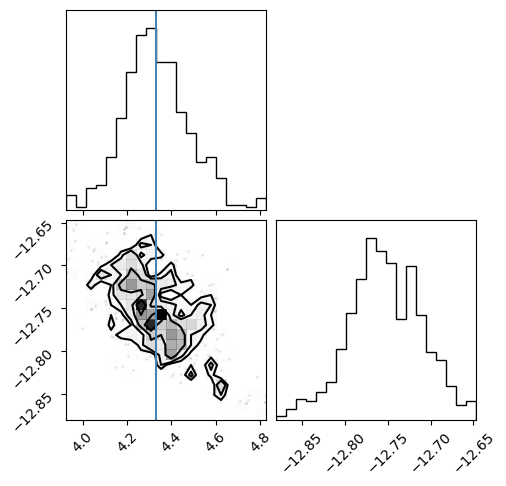

In [35]:
corner(chn[200:, -6:-4], truths=[13/3, -13.301029995663981]);

In [47]:
a = basismaps.T @ chn[randidx, :nanisopars].T
print(a.shape)

(3072, 100)


In [ ]:
np.sum(basismaps.T @ chn[randidx, :nanisopars].T, axis=1)

In [50]:
np.median?

Signature:       np.median(a, axis=None, out=None, overwrite_input=False, keepdims=False)
Call signature:  np.median(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function median at 0x7b0a9c162520>
File:            ~/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py
Docstring:      
Compute the median along the specified axis.

Returns the median of the array elements.

Parameters
----------
a : array_like
    Input array or object that can be converted to an array.
axis : {int, sequence of int, None}, optional
    Axis or axes along which the medians are computed. The default,
    axis=None, will compute the median along a flattened version of
    the array. If a sequence of axes, the array is first flattened
    along the given axes, then the median is computed along the
    resulting flattened axis.
out : ndarray, optional
    Alternative output array in which to place the result. It must
    have the same shape an

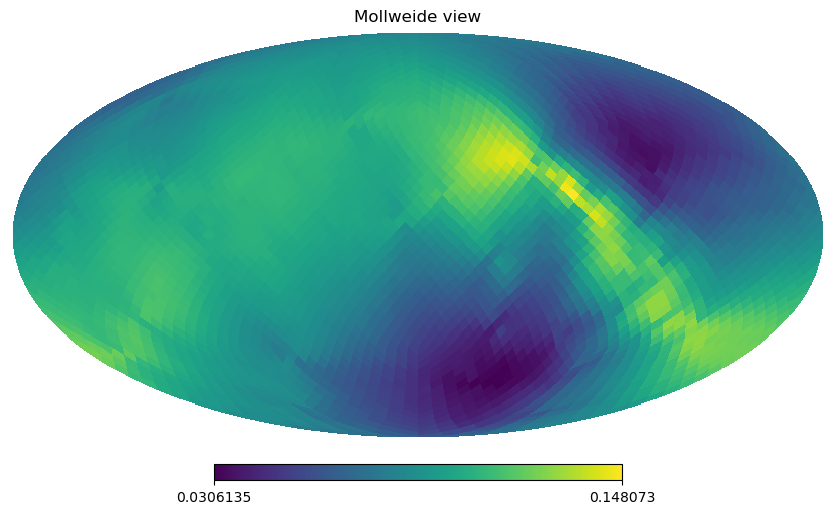

In [52]:
randidx = np.random.randint(200, 1000, size=100)
hp.mollview(np.median(basismaps.T @ chn[randidx, :nanisopars].T, axis=1))